# Study A reproducible 40-run analysis with missing-type-specific test rows

This standalone notebook consolidates the NoSpatial, XY, Z, and XYZ workflows for BM2 Study A. It generates mean and sample standard deviation over 40 paired seeds, 95% confidence intervals, constituent-model results, ensemble results, RMSE improvement tables, and paired Wilcoxon tests with Holm correction.

Important safeguards:

- The BM2 test set is not used for tuning or model selection.
- Test RMSE is evaluated on five predefined `rows` values for each missing type: MT1 uses `{0, 4, 8, 12, 16}`, MT2 uses `{1, 5, 9, 13, 17}`, MT3 uses `{2, 6, 10, 14, 18}`, and MT4 uses `{3, 7, 11, 15, 19}`.
- Preprocessing is fitted inside each cross-validation fold.
- Spatial features are assigned explicitly for every missing type.
- Duplicate training and validation IDs are removed before development data are combined.
- The pre-specified ensemble is the arithmetic mean of RF, GBR, and XGBoost predictions.


## Requirements and input files

Place the three CSV files in the same directory as this notebook, or enter their full paths in the settings cell. The test CSV must contain a unique integer `rows` column with values 0 through 19. Required packages are `numpy`, `pandas`, `scipy`, `scikit-learn`, `xgboost`, `joblib`, `matplotlib`, and `openpyxl`. The optional `psutil` package adds physical-core and memory information to the system table. If needed, install XGBoost in the active environment before starting the full experiment.


## Imports, constants, and experiment schema

In [65]:
from __future__ import annotations

import argparse
import json
import platform
import sys
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Iterable

import joblib
import numpy as np
import pandas as pd
import scipy
from scipy.stats import t as student_t
from scipy.stats import wilcoxon
import sklearn
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, GroupKFold, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


CORE_FEATURES = [
    "Sr",
    "gamma_t",
    "e",
    "LL",
    "PL",
    "w",
    "PI",
    "LI",
    "e_squared",
    "w_by_LL",
    "Sr_log",
    "moisture_void_ratio",
]

SPATIAL_FEATURES = {
    "NoSpatial": [],
    "XY": ["x", "y"],
    "Z": ["z_depth"],
    "XYZ": ["x", "y", "z_depth"],
}

CONFIG_LABELS = {
    "NoSpatial": "Without Spatial",
    "XY": "With XY",
    "Z": "With Z",
    "XYZ": "With XYZ",
}

TARGET_ORDER = ["Cc", "Cv", "Pc", "E50", "su"]
CONFIG_ORDER = ["NoSpatial", "XY", "Z", "XYZ"]
MISSING_TYPE_ORDER = ["MT1", "MT2", "MT3", "MT4"]
TEST_ROWS_BY_MISSING_TYPE = {
    "MT1": [0, 4, 8, 12, 16],
    "MT2": [1, 5, 9, 13, 17],
    "MT3": [2, 6, 10, 14, 18],
    "MT4": [3, 7, 11, 15, 19],
}
MODEL_ORDER = ["RF", "GBR", "XGB", "Ensemble"]
SPLIT_ORDER = ["Development", "Test"]

MISSINGNESS_PATTERNS = {
    "MT1": {
        "known_mechanical": [],
        "targets": ["Cc", "Cv", "Pc", "E50", "su"],
        "polynomial_degree": 1,
    },
    "MT2": {
        "known_mechanical": ["su"],
        "targets": ["Cc", "Cv", "Pc", "E50"],
        "polynomial_degree": 2,
    },
    "MT3": {
        "known_mechanical": ["su", "E50"],
        "targets": ["Cc", "Cv", "Pc"],
        "polynomial_degree": 2,
    },
    "MT4": {
        "known_mechanical": ["Pc", "Cc", "Cv"],
        "targets": ["E50", "su"],
        "polynomial_degree": 2,
    },
}


@dataclass(frozen=True)
class ExperimentTask:
    configuration: str
    missing_type: str
    target: str
    features: tuple[str, ...]
    polynomial_degree: int


## Definitions and experiment schema

In [66]:
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Generate reproducible Study A mean +/- SD tables from 40 seeded runs."
    )
    parser.add_argument(
        "--train",
        default="BM2_Train_borehole_grouped_80.csv",
        help="Development/training CSV.",
    )
    parser.add_argument(
        "--test",
        default="BM2_Test_borehole_grouped_20.csv",
        help="The Study A BM2 test CSV with a unique integer rows column.",
    )
    parser.add_argument("--output-dir", default="StudyB_40run_results_Selected22Sept")
    parser.add_argument("--runs", type=int, default=40)
    parser.add_argument("--base-seed", type=int, default=2026)
    parser.add_argument("--tuning-seed", type=int, default=1729)
    parser.add_argument("--cv-folds", type=int, default=5)
    parser.add_argument(
        "--cv-strategy",
        choices=["group", "random"],
        default="group",
        help="Use borehole-grouped CV by default; choose random to mirror the notebooks.",
    )
    parser.add_argument(
        "--search-profile",
        choices=["expanded", "manuscript", "smoke"],
        default="expanded",
        help="Expanded addresses reviewer concerns; manuscript mirrors Table 1; smoke is for testing.",
    )
    parser.add_argument(
        "--search-iterations",
        type=int,
        default=20,
        help="Randomized-search iterations per model for the expanded profile.",
    )
    parser.add_argument(
        "--tuning-score",
        choices=["rmse", "r2"],
        default="rmse",
        help="Hyperparameter selection objective. RMSE is aligned with the manuscript tables.",
    )
    parser.add_argument("--n-jobs", type=int, default=-1)
    parser.add_argument("--huber-delta", type=float, default=1.0)
    parser.add_argument(
        "--configurations",
        nargs="+",
        choices=CONFIG_ORDER,
        default=CONFIG_ORDER,
    )
    parser.add_argument(
        "--missing-types",
        nargs="+",
        choices=MISSING_TYPE_ORDER,
        default=MISSING_TYPE_ORDER,
    )
    parser.add_argument(
        "--targets",
        nargs="+",
        choices=TARGET_ORDER,
        default=None,
        help="Optional target subset for diagnostics or smoke runs.",
    )
    parser.add_argument(
        "--models",
        nargs="+",
        choices=["RF", "GBR", "XGB"],
        default=["RF", "GBR", "XGB"],
    )
    parser.add_argument(
        "--overlap-policy",
        choices=["drop-train", "error", "allow"],
        default="drop-train",
        help="How to handle exact global_id overlap between training and validation.",
    )
    parser.add_argument(
        "--save-models",
        action="store_true",
        help="Save every fitted constituent model. This can require substantial disk space.",
    )
    parser.add_argument(
        "--validate-only",
        action="store_true",
        help="Validate inputs and write manifests without fitting models.",
    )
    return parser.parse_args()


## Arguments, input loading, and leakage checks

In [67]:
def resolve_input_path(raw_path: str) -> Path:
    supplied = Path(raw_path).expanduser()
    script_location = globals().get("__file__")
    script_dir = Path(script_location).resolve().parent if script_location else Path.cwd()
    candidates = [supplied]
    if not supplied.is_absolute():
        candidates.extend(
            [
                Path.cwd() / supplied,
                script_dir / supplied,
                script_dir / "upload" / supplied.name,
            ]
        )
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        f"Could not find {raw_path!r}. Supply an explicit path with --train, --validation, or --test."
    )

def load_and_engineer(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    frame = frame.loc[:, ~frame.columns.str.startswith("Unnamed:")].copy()
    required_raw = {
        "global_id",
        "borehole_id",
        "Sr",
        "gamma_t",
        "e",
        "LL",
        "PL",
        "w",
        "su",
        "E50",
        "Pc",
        "Cc",
        "Cv",
        "x",
        "y",
        "z_depth",
    }
    missing = sorted(required_raw.difference(frame.columns))
    if missing:
        raise ValueError(f"{path.name} is missing required columns: {missing}")

    frame["PI"] = frame["LL"] - frame["PL"]
    frame["LI"] = (frame["w"] - frame["PL"]) / (frame["PI"] + 1e-5)
    frame["e_squared"] = frame["e"] ** 2
    frame["w_by_LL"] = frame["w"] / (frame["LL"] + 1e-5)
    if (frame["Sr"] + 1e-5 <= 0).any():
        raise ValueError(f"{path.name} contains Sr values that cannot be log transformed.")
    frame["Sr_log"] = np.log(frame["Sr"] + 1e-5)
    frame["moisture_void_ratio"] = frame["w"] * frame["e"]
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)

    check_columns = sorted(
        set(CORE_FEATURES)
        | {"x", "y", "z_depth", "su", "E50", "Pc", "Cc", "Cv"}
    )
    missing_counts = frame[check_columns].isna().sum()
    missing_counts = missing_counts[missing_counts > 0]
    if not missing_counts.empty:
        raise ValueError(
            f"{path.name} has missing or infinite modeling values: {missing_counts.to_dict()}"
        )
    return frame
def prepare_study_b_splits(
    train: pd.DataFrame,
    test: pd.DataFrame,
    strict_test_borehole_isolation: bool,
) -> tuple[pd.DataFrame, pd.DataFrame, list[dict[str, Any]]]:
    """Audit and lock Study B train/test data without reading test labels during fitting."""
    if train["global_id"].duplicated().any():
        duplicate_ids = train.loc[train["global_id"].duplicated(False), "global_id"].unique()
        raise ValueError(f"Training data contain duplicate global_id values: {duplicate_ids[:20]}")
    if test["global_id"].duplicated().any():
        duplicate_ids = test.loc[test["global_id"].duplicated(False), "global_id"].unique()
        raise ValueError(f"Test data contain duplicate global_id values: {duplicate_ids[:20]}")

    train_ids = set(train["global_id"])
    test_ids = set(test["global_id"])
    record_overlap = train_ids & test_ids
    if record_overlap:
        raise ValueError(
            "Direct test leakage detected. global_id values occur in both training and test data: "
            f"{sorted(record_overlap)[:20]}"
        )

    train_boreholes = set(train["borehole_id"])
    test_boreholes = set(test["borehole_id"])
    borehole_overlap = train_boreholes & test_boreholes
    if borehole_overlap and strict_test_borehole_isolation:
        raise ValueError(
            f"Spatial leakage risk: {len(borehole_overlap)} borehole_id values occur in both "
            "training and test data. Rebuild a group-disjoint train/test split, or use "
            "--no-strict-test-borehole-isolation only for a clearly declared within-borehole "
            "imputation task. Example IDs: " + str(sorted(borehole_overlap)[:20])
        )
    if borehole_overlap:
        warnings.warn(
            f"Training and test data share {len(borehole_overlap)} boreholes. Results estimate "
            "within-borehole imputation and must not be described as unseen-location generalization.",
            RuntimeWarning,
        )

    spatial_key = ["x", "y", "z_depth"]
    train_keys = set(map(tuple, train[spatial_key].round(8).to_numpy()))
    test_keys = set(map(tuple, test[spatial_key].round(8).to_numpy()))
    exact_spatial_overlap = train_keys & test_keys
    if exact_spatial_overlap:
        raise ValueError(
            f"Exact x-y-depth locations overlap between training and test data: "
            f"{len(exact_spatial_overlap)} locations."
        )

    train = train.reset_index(drop=True).copy()
    test = test.reset_index(drop=True).copy()
    train["source_split"] = "train"
    test["source_split"] = "test"
    audit = [
        {"item": "training_rows", "value": len(train)},
        {"item": "test_rows", "value": len(test)},
        {"item": "training_unique_global_ids", "value": train["global_id"].nunique()},
        {"item": "test_unique_global_ids", "value": test["global_id"].nunique()},
        {"item": "overlapping_global_ids", "value": len(record_overlap)},
        {"item": "training_boreholes", "value": train["borehole_id"].nunique()},
        {"item": "test_boreholes", "value": test["borehole_id"].nunique()},
        {"item": "overlapping_boreholes", "value": len(borehole_overlap)},
        {"item": "overlapping_exact_xyz_depth_locations", "value": len(exact_spatial_overlap)},
        {"item": "strict_test_borehole_isolation", "value": strict_test_borehole_isolation},
    ]
    return train, test, audit

def iter_tasks(args: argparse.Namespace) -> Iterable[ExperimentTask]:
    requested_targets = set(args.targets) if args.targets else None
    for missing_type in MISSING_TYPE_ORDER:
        if missing_type not in args.missing_types:
            continue
        pattern = MISSINGNESS_PATTERNS[missing_type]
        for configuration in CONFIG_ORDER:
            if configuration not in args.configurations:
                continue
            features = tuple(
                CORE_FEATURES
                + SPATIAL_FEATURES[configuration]
                + list(pattern["known_mechanical"])
            )
            for target in pattern["targets"]:
                if requested_targets is not None and target not in requested_targets:
                    continue
                yield ExperimentTask(
                    configuration=configuration,
                    missing_type=missing_type,
                    target=target,
                    features=features,
                    polynomial_degree=int(pattern["polynomial_degree"]),
                )


## Model construction and hyperparameter search

In [68]:
def get_xgb_regressor(seed: int) -> Any:
    try:
        import xgboost
        from xgboost import XGBRegressor
    except ImportError as exc:
        raise ImportError(
            "XGBoost is required for the three-model manuscript ensemble. "
            "Install it with `pip install xgboost`, or use --models RF GBR only for a smoke test."
        ) from exc
    return XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=seed,
        n_jobs=1,
        verbosity=0,
    )

def base_model(model_name: str, seed: int) -> Any:
    if model_name == "RF":
        return RandomForestRegressor(random_state=seed, n_jobs=1)
    if model_name == "GBR":
        return GradientBoostingRegressor(random_state=seed, loss="squared_error")
    if model_name == "XGB":
        return get_xgb_regressor(seed)
    raise KeyError(model_name)

def search_space(model_name: str, profile: str) -> dict[str, list[Any]]:
    prefix = "regressor__model__"
    if profile == "smoke":
        spaces = {
            "RF": {"n_estimators": [20], "max_depth": [5], "min_samples_split": [2]},
            "GBR": {"n_estimators": [20], "learning_rate": [0.05], "max_depth": [3]},
            "XGB": {"n_estimators": [20], "learning_rate": [0.05], "max_depth": [3]},
        }
    elif profile == "manuscript":
        spaces = {
            "RF": {
                "n_estimators": [100, 200, 500],
                "max_depth": [5, 10],
                "min_samples_split": [2, 5],
            },
            "GBR": {
                "n_estimators": [100, 200, 500],
                "learning_rate": [0.05, 0.1],
                "max_depth": [3, 5],
            },
            "XGB": {
                "n_estimators": [100, 200, 500],
                "learning_rate": [0.05, 0.1],
                "max_depth": [3, 5],
            },
        }
    else:
        spaces = {
            "RF": {
                "n_estimators": [200, 500, 800],
                "max_depth": [None, 5, 10, 20],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4],
                "max_features": [1.0, 0.5, "sqrt"],
            },
            "GBR": {
                "n_estimators": [100, 200, 500],
                "learning_rate": [0.03, 0.05, 0.1],
                "max_depth": [2, 3, 5],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4],
                "subsample": [0.8, 1.0],
                "max_features": [None, "sqrt"],
            },
            "XGB": {
                "n_estimators": [100, 200, 500],
                "learning_rate": [0.03, 0.05, 0.1],
                "max_depth": [3, 5, 8],
                "min_child_weight": [1, 3, 5],
                "subsample": [0.8, 1.0],
                "colsample_bytree": [0.8, 1.0],
                "reg_alpha": [0.0, 0.1],
                "reg_lambda": [1.0, 5.0],
            },
        }
    return {prefix + key: value for key, value in spaces[model_name].items()}

def build_estimator(model_name: str, degree: int, seed: int) -> TransformedTargetRegressor:
    pipeline = Pipeline(
        [
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scale", StandardScaler()),
            ("model", base_model(model_name, seed)),
        ]
    )
    return TransformedTargetRegressor(regressor=pipeline, transformer=StandardScaler())

def make_cv(
    strategy: str,
    folds: int,
    seed: int,
    groups: pd.Series,
) -> tuple[Any, np.ndarray | None]:
    if strategy == "random":
        return KFold(n_splits=folds, shuffle=True, random_state=seed), None
    unique_groups = groups.nunique()
    if unique_groups < folds:
        raise ValueError(f"Grouped CV requested {folds} folds but only {unique_groups} groups exist.")
    try:
        splitter = GroupKFold(n_splits=folds, shuffle=True, random_state=seed)
    except TypeError:
        splitter = GroupKFold(n_splits=folds)
    return splitter, groups.to_numpy()

def tune_task_models(
    task: ExperimentTask,
    development: pd.DataFrame,
    args: argparse.Namespace,
) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    X = development.loc[:, task.features]
    y = development.loc[:, task.target]
    cv, groups = make_cv(
        args.cv_strategy,
        args.cv_folds,
        args.tuning_seed,
        development["borehole_id"],
    )
    scoring = "neg_root_mean_squared_error" if args.tuning_score == "rmse" else "r2"
    estimators: dict[str, Any] = {}
    records: list[dict[str, Any]] = []

    for model_name in args.models:
        estimator = build_estimator(model_name, task.polynomial_degree, args.tuning_seed)
        params = search_space(model_name, args.search_profile)
        if args.search_profile == "expanded":
            search = RandomizedSearchCV(
                estimator=estimator,
                param_distributions=params,
                n_iter=args.search_iterations,
                scoring=scoring,
                cv=cv,
                random_state=args.tuning_seed,
                n_jobs=args.n_jobs,
                refit=True,
                return_train_score=False,
            )
        else:
            search = GridSearchCV(
                estimator=estimator,
                param_grid=params,
                scoring=scoring,
                cv=cv,
                n_jobs=args.n_jobs,
                refit=True,
                return_train_score=False,
            )
        fit_kwargs = {"groups": groups} if groups is not None else {}
        started = time.perf_counter()
        search.fit(X, y, **fit_kwargs)
        elapsed = time.perf_counter() - started
        estimators[model_name] = clone(search.best_estimator_)
        records.append(
            {
                "configuration": task.configuration,
                "configuration_label": CONFIG_LABELS[task.configuration],
                "missing_type": task.missing_type,
                "target": task.target,
                "model": model_name,
                "features": ", ".join(task.features),
                "raw_feature_count": len(task.features),
                "polynomial_degree": task.polynomial_degree,
                "expanded_feature_count": _expanded_feature_count(
                    len(task.features), task.polynomial_degree
                ),
                "cv_strategy": args.cv_strategy,
                "cv_folds": args.cv_folds,
                "tuning_score": args.tuning_score,
                "search_profile": args.search_profile,
                "best_cv_score": float(search.best_score_),
                "best_parameters": json.dumps(search.best_params_, sort_keys=True),
                "tuning_seconds": elapsed,
            }
        )
    return estimators, records

def _expanded_feature_count(raw_count: int, degree: int) -> int:
    if degree == 1:
        return raw_count
    if degree == 2:
        return raw_count + raw_count * (raw_count + 1) // 2
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    poly.fit(np.zeros((1, raw_count)))
    return int(poly.n_output_features_)

def reseed_estimator(estimator: Any, seed: int, n_jobs: int) -> Any:
    fitted = clone(estimator)
    available = fitted.get_params(deep=True)
    updates: dict[str, Any] = {}
    for name in available:
        if name.endswith("random_state"):
            updates[name] = seed
        elif name.endswith("n_jobs"):
            updates[name] = n_jobs
    if updates:
        fitted.set_params(**updates)
    return fitted


## Repeated-run evaluation and metrics

Development metrics use the complete development set. Test predictions and test metrics use only the five mapped `rows` values for the task's missing type.


In [69]:
def robust_l2(y_true: np.ndarray, y_pred: np.ndarray, delta: float) -> float:
    residual = np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float)
    absolute = np.abs(residual)
    loss = np.where(
        absolute <= delta,
        0.5 * residual**2,
        delta * (absolute - 0.5 * delta),
    )
    return float(np.mean(loss))

def calculate_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    huber_delta: float,
) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    l2 = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(l2))
    denominator = float(np.mean(np.abs(y_true)))
    rmse_percent = np.nan if denominator == 0 else 100.0 * rmse / denominator
    return {
        "rmse": rmse,
        "rmse_percent": rmse_percent,
        "l2": l2,
        "robust_l2": robust_l2(y_true, y_pred, huber_delta),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }

def evaluate_task(
    task: ExperimentTask,
    tuned_estimators: dict[str, Any],
    development: pd.DataFrame,
    test: pd.DataFrame,
    args: argparse.Namespace,
    output_dir: Path,
) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    X_development = development.loc[:, task.features]
    y_development = development.loc[:, task.target].to_numpy()
    X_test = test.loc[:, task.features]
    y_test = test.loc[:, task.target].to_numpy()
    metric_rows: list[dict[str, Any]] = []
    prediction_rows: list[dict[str, Any]] = []

    for run_index in range(args.runs):
        seed = args.base_seed + run_index
        predictions: dict[str, dict[str, np.ndarray]] = {
            "Training": {},
            "Test": {},
        }
        for model_name, template in tuned_estimators.items():
            estimator = reseed_estimator(template, seed, args.n_jobs)
            started = time.perf_counter()
            estimator.fit(X_development, y_development)
            fit_seconds = time.perf_counter() - started
            predictions["Training"][model_name] = estimator.predict(X_development)
            predictions["Test"][model_name] = estimator.predict(X_test)
            if args.save_models:
                model_dir = output_dir / "models" / task.configuration / task.missing_type / task.target
                model_dir.mkdir(parents=True, exist_ok=True)
                joblib.dump(estimator, model_dir / f"{model_name}_seed_{seed}.joblib")

            for split, truth in [("Training", y_development), ("Test", y_test)]:
                values = calculate_metrics(
                    truth,
                    predictions[split][model_name],
                    args.huber_delta,
                )
                metric_rows.append(
                    _metric_record(task, run_index, seed, model_name, split, len(truth), fit_seconds, values)
                )

        for split, truth in [("Training", y_development), ("Test", y_test)]:
            ensemble_prediction = np.mean(
                np.column_stack([predictions[split][name] for name in args.models]),
                axis=1,
            )
            predictions[split]["Ensemble"] = ensemble_prediction
            values = calculate_metrics(truth, ensemble_prediction, args.huber_delta)
            metric_rows.append(
                _metric_record(task, run_index, seed, "Ensemble", split, len(truth), np.nan, values)
            )

        for row_position, (_, source_row) in enumerate(test.iterrows()):
            record = {
                "run": run_index + 1,
                "seed": seed,
                "configuration": task.configuration,
                "configuration_label": CONFIG_LABELS[task.configuration],
                "missing_type": task.missing_type,
                "target": task.target,
                "test_row": row_position + 1,
                "global_id": source_row["global_id"],
                "borehole_id": source_row["borehole_id"],
                "actual": y_test[row_position],
            }
            for model_name in args.models + ["Ensemble"]:
                record[f"prediction_{model_name}"] = predictions["Test"][model_name][row_position]
            prediction_rows.append(record)

        print(
            f"  completed {task.configuration} {task.missing_type} {task.target}, "
            f"run {run_index + 1}/{args.runs}, seed={seed}",
            flush=True,
        )
    return metric_rows, prediction_rows

def _metric_record(
    task: ExperimentTask,
    run_index: int,
    seed: int,
    model: str,
    split: str,
    sample_count: int,
    fit_seconds: float,
    values: dict[str, float],
) -> dict[str, Any]:
    return {
        "run": run_index + 1,
        "seed": seed,
        "configuration": task.configuration,
        "configuration_label": CONFIG_LABELS[task.configuration],
        "missing_type": task.missing_type,
        "target": task.target,
        "model": model,
        "split": split,
        "n": sample_count,
        "fit_seconds": fit_seconds,
        **values,
    }


## Uncertainty summaries and paired statistical tests

In [70]:
def summarize_metrics(run_metrics: pd.DataFrame) -> pd.DataFrame:
    identifiers = [
        "configuration",
        "configuration_label",
        "missing_type",
        "target",
        "model",
        "split",
        "n",
    ]
    metrics = ["rmse", "rmse_percent", "l2", "robust_l2", "mae", "r2"]
    grouped = run_metrics.groupby(identifiers, sort=False, dropna=False)
    rows: list[dict[str, Any]] = []
    for keys, group in grouped:
        row = dict(zip(identifiers, keys))
        row["runs"] = len(group)
        critical = student_t.ppf(0.975, df=max(len(group) - 1, 1))
        for metric in metrics:
            values = group[metric].to_numpy(dtype=float)
            mean = float(np.mean(values))
            std = float(np.std(values, ddof=1)) if len(values) > 1 else np.nan
            margin = critical * std / np.sqrt(len(values)) if len(values) > 1 else np.nan
            row[f"{metric}_mean"] = mean
            row[f"{metric}_sd"] = std
            row[f"{metric}_ci95_low"] = mean - margin if len(values) > 1 else np.nan
            row[f"{metric}_ci95_high"] = mean + margin if len(values) > 1 else np.nan
        rows.append(row)
    result = pd.DataFrame(rows)
    return sort_results(result)


def calculate_improvements(run_metrics: pd.DataFrame) -> pd.DataFrame:
    ensemble = run_metrics.loc[run_metrics["model"] == "Ensemble"].copy()
    baseline = ensemble.loc[ensemble["configuration"] == "NoSpatial", [
        "run", "seed", "missing_type", "target", "split", "rmse", "rmse_percent"
    ]].rename(columns={"rmse": "baseline_rmse", "rmse_percent": "baseline_rmse_percent"})
    spatial = ensemble.loc[ensemble["configuration"] != "NoSpatial"].copy()
    merged = spatial.merge(
        baseline,
        on=["run", "seed", "missing_type", "target", "split"],
        how="left",
        validate="many_to_one",
    )
    if merged[["baseline_rmse", "baseline_rmse_percent"]].isna().any().any():
        raise ValueError("Improvement tables require NoSpatial results for every selected task.")
    merged["rmse_improvement_percent"] = 100.0 * (
        merged["baseline_rmse"] - merged["rmse"]
    ) / merged["baseline_rmse"]
    merged["rmse_percent_improvement_percent"] = 100.0 * (
        merged["baseline_rmse_percent"] - merged["rmse_percent"]
    ) / merged["baseline_rmse_percent"]
    columns = [
        "run",
        "seed",
        "configuration",
        "configuration_label",
        "missing_type",
        "target",
        "split",
        "baseline_rmse",
        "rmse",
        "rmse_improvement_percent",
        "baseline_rmse_percent",
        "rmse_percent",
        "rmse_percent_improvement_percent",
    ]
    return sort_results(merged[columns])


def summarize_improvements(improvements: pd.DataFrame) -> pd.DataFrame:
    identifiers = ["configuration", "configuration_label", "missing_type", "target", "split"]
    rows: list[dict[str, Any]] = []
    for keys, group in improvements.groupby(identifiers, sort=False):
        row = dict(zip(identifiers, keys))
        row["runs"] = len(group)
        for metric in ["rmse_improvement_percent", "rmse_percent_improvement_percent"]:
            values = group[metric].to_numpy(float)
            row[f"{metric}_mean"] = float(values.mean())
            row[f"{metric}_sd"] = float(values.std(ddof=1)) if len(values) > 1 else np.nan
        rows.append(row)
    return sort_results(pd.DataFrame(rows))


def holm_adjust(p_values: np.ndarray) -> np.ndarray:
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted_sorted = np.empty_like(p_values)
    running = 0.0
    total = len(p_values)
    for rank, original_index in enumerate(order):
        candidate = min(1.0, (total - rank) * p_values[original_index])
        running = max(running, candidate)
        adjusted_sorted[original_index] = running
    return adjusted_sorted


def paired_tests(run_metrics: pd.DataFrame) -> pd.DataFrame:
    ensemble_test = run_metrics.loc[
        (run_metrics["model"] == "Ensemble") & (run_metrics["split"] == "Test")
    ].copy()
    rows: list[dict[str, Any]] = []
    for (missing_type, target, configuration), spatial in ensemble_test.loc[
        ensemble_test["configuration"] != "NoSpatial"
    ].groupby(["missing_type", "target", "configuration"], sort=False):
        baseline = ensemble_test.loc[
            (ensemble_test["missing_type"] == missing_type)
            & (ensemble_test["target"] == target)
            & (ensemble_test["configuration"] == "NoSpatial"),
            ["seed", "rmse"],
        ].rename(columns={"rmse": "baseline_rmse"})
        paired = spatial[["seed", "rmse"]].merge(baseline, on="seed", validate="one_to_one")
        difference = paired["rmse"].to_numpy() - paired["baseline_rmse"].to_numpy()
        if len(difference) < 2 or np.allclose(difference, 0):
            statistic, p_value = np.nan, 1.0
        else:
            result = wilcoxon(difference, alternative="two-sided", zero_method="wilcox")
            statistic, p_value = float(result.statistic), float(result.pvalue)
        sd = float(np.std(difference, ddof=1)) if len(difference) > 1 else np.nan
        rows.append(
            {
                "missing_type": missing_type,
                "target": target,
                "configuration": configuration,
                "configuration_label": CONFIG_LABELS[configuration],
                "paired_runs": len(difference),
                "mean_rmse_difference_spatial_minus_baseline": float(np.mean(difference)),
                "median_rmse_difference_spatial_minus_baseline": float(np.median(difference)),
                "paired_effect_size_dz": float(np.mean(difference) / sd) if sd and np.isfinite(sd) else np.nan,
                "wilcoxon_statistic": statistic,
                "p_value_two_sided": p_value,
            }
        )
    result = pd.DataFrame(rows)
    if not result.empty:
        result["p_value_holm"] = holm_adjust(result["p_value_two_sided"].to_numpy())
        result["significant_holm_0.05"] = result["p_value_holm"] < 0.05
    return sort_results(result)


## Manuscript tables and exports

In [71]:
def mean_sd_text(mean: float, sd: float, target: str, metric: str) -> str:
    if pd.isna(mean):
        return ""
    if target == "Cc" and metric not in {"rmse_percent", "r2"}:
        digits = 4
    elif metric in {"rmse_percent", "r2"}:
        digits = 3
    elif target in {"E50", "Cv"}:
        digits = 2
    else:
        digits = 3
    if pd.isna(sd):
        return f"{mean:.{digits}f}"
    return f"{mean:.{digits}f} +/- {sd:.{digits}f}"


def manuscript_performance_table(summary: pd.DataFrame, missing_type: str) -> pd.DataFrame:
    data = summary.loc[
        (summary["model"] == "Ensemble") & (summary["missing_type"] == missing_type)
    ].copy()
    rows: list[dict[str, Any]] = []
    metrics = ["rmse", "rmse_percent", "l2", "robust_l2"]
    for configuration in CONFIG_ORDER:
        for target in TARGET_ORDER:
            subset = data.loc[
                (data["configuration"] == configuration) & (data["target"] == target)
            ]
            if subset.empty:
                continue
            row: dict[str, Any] = {
                "Configuration": CONFIG_LABELS[configuration],
                "Target": target,
            }
            for split in SPLIT_ORDER:
                split_row = subset.loc[subset["split"] == split]
                if split_row.empty:
                    continue
                values = split_row.iloc[0]
                for metric in metrics:
                    label = {
                        "rmse": "RMSE",
                        "rmse_percent": "RMSE%",
                        "l2": "L2",
                        "robust_l2": "Robust L2",
                    }[metric]
                    row[f"{split} {label}"] = mean_sd_text(
                        values[f"{metric}_mean"], values[f"{metric}_sd"], target, metric
                    )
            rows.append(row)
    return pd.DataFrame(rows)


def manuscript_ablation_table(summary: pd.DataFrame) -> pd.DataFrame:
    data = summary.loc[summary["split"] == "Test"].copy()
    rows: list[dict[str, Any]] = []
    for missing_type in MISSING_TYPE_ORDER:
        for target in TARGET_ORDER:
            for configuration in CONFIG_ORDER:
                subset = data.loc[
                    (data["missing_type"] == missing_type)
                    & (data["target"] == target)
                    & (data["configuration"] == configuration)
                ]
                if subset.empty:
                    continue
                row = {
                    "Missing Type": missing_type,
                    "Target": target,
                    "Configuration": CONFIG_LABELS[configuration],
                }
                for model in MODEL_ORDER:
                    model_row = subset.loc[subset["model"] == model]
                    if model_row.empty:
                        continue
                    values = model_row.iloc[0]
                    row[f"{model} test RMSE"] = mean_sd_text(
                        values["rmse_mean"], values["rmse_sd"], target, "rmse"
                    )
                rows.append(row)
    return pd.DataFrame(rows)


def manuscript_improvement_table(improvement_summary: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for missing_type in MISSING_TYPE_ORDER:
        for target in TARGET_ORDER:
            for configuration in ["XY", "Z", "XYZ"]:
                subset = improvement_summary.loc[
                    (improvement_summary["missing_type"] == missing_type)
                    & (improvement_summary["target"] == target)
                    & (improvement_summary["configuration"] == configuration)
                ]
                if subset.empty:
                    continue
                row = {
                    "Missing Type": missing_type,
                    "Target": target,
                    "Configuration": CONFIG_LABELS[configuration],
                }
                for split in SPLIT_ORDER:
                    split_row = subset.loc[subset["split"] == split]
                    if split_row.empty:
                        continue
                    values = split_row.iloc[0]
                    mean = values["rmse_improvement_percent_mean"]
                    sd = values["rmse_improvement_percent_sd"]
                    row[f"{split} RMSE improvement (%)"] = (
                        f"{mean:.2f} +/- {sd:.2f}" if pd.notna(sd) else f"{mean:.2f}"
                    )
                rows.append(row)
    return pd.DataFrame(rows)


def sort_results(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame
    result = frame.copy()
    sort_columns: list[str] = []
    temporary: list[str] = []
    mappings = {
        "configuration": CONFIG_ORDER,
        "missing_type": MISSING_TYPE_ORDER,
        "target": TARGET_ORDER,
        "model": MODEL_ORDER,
        "split": SPLIT_ORDER,
    }
    for column, order in mappings.items():
        if column in result.columns:
            helper = f"__order_{column}"
            result[helper] = pd.Categorical(result[column], categories=order, ordered=True)
            sort_columns.append(helper)
            temporary.append(helper)
    for column in ["run", "seed", "test_row"]:
        if column in result.columns:
            sort_columns.append(column)
    if sort_columns:
        result = result.sort_values(sort_columns, kind="stable")
    return result.drop(columns=temporary).reset_index(drop=True)


def write_excel(output_path: Path, sheets: dict[str, pd.DataFrame]) -> None:
    try:
        with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
            for sheet_name, frame in sheets.items():
                safe_name = sheet_name[:31]
                frame.to_excel(writer, sheet_name=safe_name, index=False)
                worksheet = writer.book[safe_name]
                worksheet.freeze_panes = "A2"
                worksheet.auto_filter.ref = worksheet.dimensions
                for column_cells in worksheet.columns:
                    width = min(
                        55,
                        max(len(str(cell.value)) if cell.value is not None else 0 for cell in column_cells)
                        + 2,
                    )
                    worksheet.column_dimensions[column_cells[0].column_letter].width = width
    except ImportError as exc:
        warnings.warn(f"Excel workbook was not written because openpyxl is unavailable: {exc}")


def software_versions() -> dict[str, str]:
    versions = {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "scipy": scipy.__version__,
        "joblib": joblib.__version__,
    }
    try:
        import xgboost

        versions["xgboost"] = xgboost.__version__
    except ImportError:
        versions["xgboost"] = "not installed"
    return versions


def write_manifests(
    output_dir: Path,
    args: argparse.Namespace,
    tasks: list[ExperimentTask],
    audit: list[dict[str, Any]],
    input_paths: dict[str, Path],
) -> None:
    pd.DataFrame(audit).to_csv(output_dir / "sample_count_and_overlap_audit.csv", index=False)
    feature_rows = []
    for task in tasks:
        feature_rows.append(
            {
                **asdict(task),
                "configuration_label": CONFIG_LABELS[task.configuration],
                "features": ", ".join(task.features),
                "raw_feature_count": len(task.features),
                "expanded_feature_count": _expanded_feature_count(
                    len(task.features), task.polynomial_degree
                ),
            }
        )
    pd.DataFrame(feature_rows).to_csv(output_dir / "feature_manifest.csv", index=False)
    manifest = {
        "arguments": vars(args),
        "input_paths": {key: str(value) for key, value in input_paths.items()},
        "software_versions": software_versions(),
        "metric_definitions": {
            "rmse": "sqrt(mean((actual - predicted)^2))",
            "rmse_percent": "100 * RMSE / mean(abs(actual))",
            "l2": "mean((actual - predicted)^2)",
            "robust_l2": (
                "mean Huber loss: 0.5*r^2 when abs(r)<=delta; "
                "delta*(abs(r)-0.5*delta) otherwise"
            ),
            "huber_delta": args.huber_delta,
            "standard_deviation": "sample SD across paired random seeds (ddof=1)",
        },
        "selection_rule": (
            "Hyperparameters selected using development data only. Test labels are used only "
            "for locked final evaluation. The ensemble is a pre-specified arithmetic mean."
        ),
    }
    (output_dir / "experiment_manifest.json").write_text(
        json.dumps(manifest, indent=2, default=str), encoding="utf-8"
    )


## Experiment driver

In [72]:
def main_study_b() -> int:
    args = parse_args()
    if args.runs < 2 and not args.validate_only:
        warnings.warn("At least two runs are required to estimate a standard deviation.")
    if args.huber_delta <= 0:
        raise ValueError("--huber-delta must be positive.")
    if args.search_iterations < 1:
        raise ValueError("--search-iterations must be at least 1.")

    paths = {
        "train": resolve_input_path(args.train),
        "test": resolve_input_path(args.test),
    }
    output_dir = Path(args.output_dir).expanduser().resolve()
    output_dir.mkdir(parents=True, exist_ok=True)

    print("Loading and auditing Study B train/test data...", flush=True)
    train = load_and_engineer(paths["train"])
    test = load_and_engineer(paths["test"])
    train, test, audit = prepare_study_b_splits(
        train, test, args.strict_test_borehole_isolation
    )
    tasks = list(iter_tasks(args))
    if len(tasks) != 56 and args.targets is None and set(args.configurations) == set(CONFIG_ORDER)             and set(args.missing_types) == set(MISSING_TYPE_ORDER):
        raise AssertionError(f"Expected 56 full-study tasks but constructed {len(tasks)}.")
    if not tasks:
        raise ValueError("No experiment tasks remain after applying the requested filters.")

    write_manifests(output_dir, args, tasks, audit, paths)
    print(pd.DataFrame(audit).to_string(index=False), flush=True)
    print(f"Experiment tasks: {len(tasks)}", flush=True)
    print("Cross-validation: borehole-grouped five-fold CV on training data only", flush=True)
    if args.validate_only:
        print(f"Validation complete. Manifests written to {output_dir}")
        return 0
    if "XGB" in args.models:
        get_xgb_regressor(args.tuning_seed)
    if "NoSpatial" not in args.configurations:
        warnings.warn("NoSpatial was omitted, so improvement tables cannot be generated.")

    all_metrics: list[dict[str, Any]] = []
    all_predictions: list[dict[str, Any]] = []
    all_hyperparameters: list[dict[str, Any]] = []

    for task_number, task in enumerate(tasks, start=1):
        print(
            f"[{task_number}/{len(tasks)}] Tuning {task.configuration} "
            f"{task.missing_type} {task.target} using grouped CV on training only...",
            flush=True,
        )
        tuned, tuning_records = tune_task_models(task, train, args)
        all_hyperparameters.extend(tuning_records)
        metric_rows, prediction_rows = evaluate_task(
            task, tuned, train, test, args, output_dir
        )
        all_metrics.extend(metric_rows)
        all_predictions.extend(prediction_rows)

        pd.DataFrame(all_hyperparameters).to_csv(
            output_dir / "selected_hyperparameters_checkpoint.csv", index=False
        )
        pd.DataFrame(all_metrics).to_csv(
            output_dir / "run_metrics_checkpoint.csv", index=False
        )

    run_metrics = sort_results(pd.DataFrame(all_metrics))
    predictions = sort_results(pd.DataFrame(all_predictions))
    hyperparameters = sort_results(pd.DataFrame(all_hyperparameters))
    summary = summarize_metrics(run_metrics)

    run_metrics.to_csv(output_dir / "run_metrics_all_models.csv", index=False)
    predictions.to_csv(output_dir / "test_predictions_all_runs.csv", index=False)
    hyperparameters.to_csv(output_dir / "selected_hyperparameters.csv", index=False)
    summary.to_csv(output_dir / "summary_metrics_mean_sd_ci95.csv", index=False)

    table3 = manuscript_performance_table(summary, "MT1")
    ablation = manuscript_ablation_table(summary)
    table3.to_csv(output_dir / "Table3_StudyB_MT1_mean_SD.csv", index=False)
    ablation.to_csv(output_dir / "StudyB_model_ablation_mean_SD.csv", index=False)

    per_missing_type: dict[str, pd.DataFrame] = {}
    for missing_type in MISSING_TYPE_ORDER:
        table = manuscript_performance_table(summary, missing_type)
        if table.empty:
            continue
        per_missing_type[missing_type] = table
        table.to_csv(
            output_dir / f"StudyB_{missing_type}_performance_mean_SD.csv", index=False
        )

    improvement_summary = pd.DataFrame()
    tests = pd.DataFrame()
    table4 = pd.DataFrame()
    if "NoSpatial" in args.configurations and any(
        config in args.configurations for config in ["XY", "Z", "XYZ"]
    ):
        improvement_runs = calculate_improvements(run_metrics)
        improvement_summary = summarize_improvements(improvement_runs)
        tests = paired_tests(run_metrics)
        table4 = manuscript_improvement_table(improvement_summary)
        improvement_runs.to_csv(output_dir / "improvements_by_run.csv", index=False)
        improvement_summary.to_csv(output_dir / "improvements_mean_SD.csv", index=False)
        tests.to_csv(output_dir / "paired_wilcoxon_tests_test_RMSE.csv", index=False)
        table4.to_csv(
            output_dir / "Table4_StudyB_train_test_improvements_mean_SD.csv", index=False
        )

    sheets: dict[str, pd.DataFrame] = {
        "Table3_MT1": table3,
        "Model_Ablation": ablation,
        "Metrics_Summary": summary,
        "Hyperparameters": hyperparameters,
        "Leakage_Audit": pd.DataFrame(audit),
    }
    for missing_type, table in per_missing_type.items():
        sheets[f"Performance_{missing_type}"] = table
    if not table4.empty:
        sheets["Table4_Improvements"] = table4
        sheets["Improvement_Numeric"] = improvement_summary
        sheets["Paired_Tests"] = tests
    write_excel(output_dir / "StudyB_manuscript_tables_40_runs.xlsx", sheets)

    print(f"Completed. Results written to {output_dir}", flush=True)
    return 0


## Experiment settings

In [73]:
# Edit this cell before running the experiment.
NOTEBOOK_ARGS = [
    "--train", "BM2_Train_borehole_grouped_80.csv",
    "--test", "BM2_Test_borehole_grouped_20.csv",
    "--output-dir", "StudyB_40run_results_Selected23Sept",
    "--runs", "40",
    "--base-seed", "2026",
    "--tuning-seed", "1729",
    "--cv-folds", "5",
    "--cv-strategy", "group",
    "--search-profile", "expanded",
    "--search-iterations", "20",
    "--tuning-score", "rmse",
    "--n-jobs", "-1",
    "--huber-delta", "1.0",
]

# Set to True only when ready for the complete experiment.
# The expanded 56-task analysis performs thousands of model fits.
RUN_FULL_EXPERIMENT = False #False


## Notebook execution helper

## Run the complete experiment

The default expanded search directly addresses the reviewer request for broader and equal hyperparameter optimization. For a closer reproduction of the submitted Table 1 grid, change `expanded` to `manuscript`.


In [74]:
if RUN_FULL_EXPERIMENT:
    run_study_b(NOTEBOOK_ARGS)
else:
    print(
        "Validation is complete. Set RUN_FULL_EXPERIMENT = True in the settings cell "
        "and rerun this cell to launch the complete 40-run analysis."
    )


Validation is complete. Set RUN_FULL_EXPERIMENT = True in the settings cell and rerun this cell to launch the complete 40-run analysis.


In [75]:
whos

Variable                          Type                    Data/Info
-------------------------------------------------------------------
Any                               _AnyMeta                typing.Any
BACKGROUND_SIZE                   int                     50
CONFIG_LABELS                     dict                    n=4
CONFIG_ORDER                      list                    n=4
CORE_FEATURES                     list                    n=12
ExperimentTask                    type                    <class '__main__.ExperimentTask'>
GENERATE_MULTIRUN_LOSS_CURVES     bool                    True
GradientBoostingRegressor         ABCMeta                 <class 'sklearn.ensemble.<...>adientBoostingRegressor'>
GridSearchCV                      ABCMeta                 <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
GroupKFold                        ABCMeta                 <class 'sklearn.model_sel<...>ction._split.GroupKFold'>
GroupShuffleSplit                 ABCMeta         

## Reproducibility report: system, libraries, and computation time

Run the following cells after the complete experiment. They produce CSV files and a manuscript-ready LaTeX file describing the hardware, software environment, and measured computation times. The timing table distinguishes hyperparameter search, repeated model fitting, diagnostic loss-curve generation, and the complete pipeline wall-clock time.


In [85]:
from importlib import metadata as importlib_metadata
import os
import subprocess

try:
    from IPython.display import display
except ImportError:
    def display(value: Any) -> None:
        print(value)


def notebook_args_namespace(notebook_args: list[str]) -> argparse.Namespace:
    """Parse NOTEBOOK_ARGS without permanently changing the Jupyter kernel arguments."""
    original_argv = sys.argv[:]
    try:
        sys.argv = ["study_a_notebook"] + list(notebook_args)
        return parse_args()
    finally:
        sys.argv = original_argv


def installed_version(distribution: str) -> str:
    try:
        return importlib_metadata.version(distribution)
    except importlib_metadata.PackageNotFoundError:
        return "not installed"


def cpu_model_name() -> str:
    processor = platform.processor().strip()
    if processor:
        return processor
    cpuinfo = Path("/proc/cpuinfo")
    if cpuinfo.is_file():
        for line in cpuinfo.read_text(encoding="utf-8", errors="ignore").splitlines():
            if line.lower().startswith("model name"):
                return line.split(":", 1)[-1].strip()
    return "not reported"


def gpu_description() -> str:
    try:
        completed = subprocess.run(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.total,driver_version",
                "--format=csv,noheader",
            ],
            check=True,
            capture_output=True,
            text=True,
            timeout=10,
        )
        values = [line.strip() for line in completed.stdout.splitlines() if line.strip()]
        return "; ".join(values) if values else "not detected"
    except (FileNotFoundError, subprocess.SubprocessError):
        return "not detected"


def system_configuration_table() -> pd.DataFrame:
    try:
        import psutil

        physical_cores = psutil.cpu_count(logical=False)
        logical_cores = psutil.cpu_count(logical=True)
        memory_gib = psutil.virtual_memory().total / (1024 ** 3)
        memory_text = f"{memory_gib:.2f} GiB"
    except ImportError:
        physical_cores = "not reported"
        logical_cores = os.cpu_count() or "not reported"
        memory_text = "not reported (install psutil)"

    rows = [
        ("Operating system", platform.platform()),
        ("Machine architecture", platform.machine() or "not reported"),
        ("CPU model", cpu_model_name()),
        ("Physical CPU cores", physical_cores),
        ("Logical CPU cores", logical_cores),
        ("System memory", memory_text),
        ("GPU name, memory, driver", gpu_description()),
        ("Python implementation", platform.python_implementation()),
        ("Python version", platform.python_version()),
    ]
    return pd.DataFrame(rows, columns=["Component", "Configuration"])


def programming_libraries_table() -> pd.DataFrame:
    distributions = [
        ("NumPy", "numpy"),
        ("pandas", "pandas"),
        ("SciPy", "scipy"),
        ("scikit-learn", "scikit-learn"),
        ("joblib", "joblib"),
        ("XGBoost", "xgboost"),
        ("Matplotlib", "matplotlib"),
        ("SHAP", "shap"),
        ("psutil", "psutil"),
        ("Jupyter", "jupyter"),
        ("IPython kernel", "ipykernel"),
    ]
    return pd.DataFrame(
        [(label, installed_version(distribution)) for label, distribution in distributions],
        columns=["Library", "Version"],
    )


def _timing_summary(
    values: pd.Series,
    stage: str,
    model: str,
    notes: str,
) -> dict[str, Any]:
    numeric = pd.to_numeric(values, errors="coerce").dropna()
    if numeric.empty:
        return {
            "Stage": stage,
            "Model": model,
            "Timed operations": 0,
            "Total seconds": np.nan,
            "Total minutes": np.nan,
            "Mean seconds": np.nan,
            "SD seconds": np.nan,
            "Minimum seconds": np.nan,
            "Maximum seconds": np.nan,
            "Notes": notes,
        }
    return {
        "Stage": stage,
        "Model": model,
        "Timed operations": int(numeric.size),
        "Total seconds": float(numeric.sum()),
        "Total minutes": float(numeric.sum() / 60.0),
        "Mean seconds": float(numeric.mean()),
        "SD seconds": float(numeric.std(ddof=1)) if numeric.size > 1 else 0.0,
        "Minimum seconds": float(numeric.min()),
        "Maximum seconds": float(numeric.max()),
        "Notes": notes,
    }


def computation_time_table(
    output_dir: Path,
    loss_curve_timing: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Aggregate durations without double-counting Development/Test metric rows."""
    records: list[dict[str, Any]] = []

    hyperparameter_path = output_dir / "selected_hyperparameters.csv"
    if hyperparameter_path.is_file():
        tuned = pd.read_csv(hyperparameter_path)
        if "tuning_seconds" in tuned:
            for model, subset in tuned.groupby("model", sort=False):
                records.append(
                    _timing_summary(
                        subset["tuning_seconds"],
                        "Hyperparameter optimization",
                        str(model),
                        "One timed search per target, missing type, and feature configuration.",
                    )
                )

    run_metrics_path = output_dir / "run_metrics_all_models.csv"
    if run_metrics_path.is_file():
        metrics = pd.read_csv(run_metrics_path)
        required = {"split", "model", "fit_seconds"}
        if required.issubset(metrics.columns):
            fits = metrics.loc[
                (metrics["split"] == "Development") & (metrics["model"] != "Ensemble")
            ].copy()
            for model, subset in fits.groupby("model", sort=False):
                records.append(
                    _timing_summary(
                        subset["fit_seconds"],
                        "Repeated model fitting",
                        str(model),
                        "Development rows only; duplicate Test metric rows are excluded.",
                    )
                )

    if loss_curve_timing is not None and not loss_curve_timing.empty:
        for model, subset in loss_curve_timing.groupby("model", sort=False):
            records.append(
                _timing_summary(
                    subset["fit_seconds"],
                    "Multi-run loss-curve diagnostics",
                    str(model),
                    "Borehole-disjoint development/validation split; diagnostic only.",
                )
            )

    wall_clock_path = output_dir / "pipeline_wall_clock_time.csv"
    if wall_clock_path.is_file():
        wall_clock = pd.read_csv(wall_clock_path)
        if {"stage", "elapsed_seconds"}.issubset(wall_clock.columns):
            for _, row in wall_clock.iterrows():
                records.append(
                    _timing_summary(
                        pd.Series([row["elapsed_seconds"]]),
                        str(row["stage"]),
                        "All models",
                        "End-to-end wall-clock time measured with time.perf_counter().",
                    )
                )

    return pd.DataFrame(records)


def latex_escape(value: Any) -> str:
    if pd.isna(value):
        return "--"
    text = f"{value:.3f}" if isinstance(value, (float, np.floating)) else str(value)
    for original, escaped in [
        ("&", r"\&"), ("%", r"\%"), ("$", r"\$"),
        ("#", r"\#"), ("_", r"\_"),
    ]:
        text = text.replace(original, escaped)
    return text


def dataframe_to_latex(frame: pd.DataFrame, caption: str, label: str) -> str:
    alignment = "l" + "r" * max(0, len(frame.columns) - 1)
    header = " & ".join(latex_escape(column) for column in frame.columns) + r" \\"
    rows = [
        " & ".join(latex_escape(value) for value in row) + r" \\"
        for row in frame.itertuples(index=False, name=None)
    ]
    return "\n".join([
        r"\begin{table*}[htbp]",
        r"\centering",
        f"\\caption{{{latex_escape(caption)}}}",
        f"\\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%",
        f"\\begin{{tabular}}{{{alignment}}}",
        r"\toprule",
        header,
        r"\midrule",
        *rows,
        r"\bottomrule",
        r"\end{tabular}%",
        r"}",
        r"\end{table*}",
    ])


def write_reproducibility_report(
    output_dir: Path,
    loss_curve_timing: pd.DataFrame | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    output_dir.mkdir(parents=True, exist_ok=True)
    system = system_configuration_table()
    libraries = programming_libraries_table()
    timings = computation_time_table(output_dir, loss_curve_timing)

    system.to_csv(output_dir / "system_configuration.csv", index=False)
    libraries.to_csv(output_dir / "programming_libraries.csv", index=False)
    timings.to_csv(output_dir / "computation_times.csv", index=False)

    latex_parts = [
        r"% Requires \usepackage{booktabs} and \usepackage{graphicx}",
        dataframe_to_latex(
            system,
            "System configuration used for the experiments.",
            "tab:system_configuration",
        ),
        dataframe_to_latex(
            libraries,
            "Principal programming libraries and versions.",
            "tab:programming_libraries",
        ),
        dataframe_to_latex(
            timings,
            "Measured computation times for model development and diagnostics.",
            "tab:computation_times",
        ),
    ]
    (output_dir / "reproducibility_tables.tex").write_text(
        "\n\n".join(latex_parts), encoding="utf-8"
    )
    return system, libraries, timings


## Borehole-disjoint training and validation loss curves across runs

These curves are diagnostics, not a second model-selection step. For each seed, the development pool is split by borehole, preprocessing is fitted on the training portion only, and the locked hyperparameters selected by the main pipeline are reused. XGBoost uses its per-iteration evaluation history, Gradient Boosting uses staged predictions, and Random Forest uses warm-started tree checkpoints. RMSE is calculated on the target standardized from the training subset.


In [86]:
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit

LOSS_CURVE_MODEL_ORDER = ["XGB", "GBR", "RF"]
LOSS_CURVE_MODEL_LABELS = {
    "XGB": "XGBoost", "GBR": "Gradient Boosting", "RF": "Random Forest",
}
LOSS_CURVE_TARGET_LABELS = {
    "su": r"$S_u$", "E50": r"$E_{50}$", "Pc": r"$P_c$",
    "Cc": r"$C_c$", "Cv": r"$C_v$",
}


def load_development_pool(args: argparse.Namespace) -> pd.DataFrame:
    train = load_and_engineer(resolve_input_path(args.train))
    #validation = load_and_engineer(resolve_input_path(args.validation))
    #overlapping_ids = set(train["global_id"]) & set(validation["global_id"])
    #if overlapping_ids and args.overlap_policy == "error":
    #    raise ValueError(
    #        f"Training and validation overlap by {len(overlapping_ids)} global_id values."
    #    )
    #if overlapping_ids and args.overlap_policy == "drop-train":
    #    train = train.loc[~train["global_id"].isin(overlapping_ids)].copy()
    development = train #pd.concat([train, validation], ignore_index=True)
    return development.drop_duplicates(subset="global_id", keep="last").reset_index(drop=True)


def selected_model_parameters(
    selected: pd.DataFrame,
    missing_type: str,
    configuration: str,
    target: str,
    model_name: str,
) -> dict[str, Any]:
    match = selected.loc[
        (selected["missing_type"] == missing_type)
        & (selected["configuration"] == configuration)
        & (selected["target"] == target)
        & (selected["model"] == model_name)
    ]
    if len(match) != 1:
        raise ValueError(
            "Expected one selected-hyperparameter row for "
            f"{missing_type}/{configuration}/{target}/{model_name}, found {len(match)}."
        )
    raw = json.loads(match.iloc[0]["best_parameters"])
    prefix = "regressor__model__"
    return {
        (key[len(prefix):] if key.startswith(prefix) else key): value
        for key, value in raw.items()
    }


def fit_curve_preprocessing(
    train_frame: pd.DataFrame,
    validation_frame: pd.DataFrame,
    features: list[str],
    target: str,
    polynomial_degree: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    polynomial = PolynomialFeatures(degree=polynomial_degree, include_bias=False)
    x_train = polynomial.fit_transform(train_frame.loc[:, features])
    x_validation = polynomial.transform(validation_frame.loc[:, features])
    x_scaler = StandardScaler()
    x_train = x_scaler.fit_transform(x_train)
    x_validation = x_scaler.transform(x_validation)
    y_scaler = StandardScaler()
    y_train = y_scaler.fit_transform(
        train_frame.loc[:, [target]].to_numpy(dtype=float)
    ).ravel()
    y_validation = y_scaler.transform(
        validation_frame.loc[:, [target]].to_numpy(dtype=float)
    ).ravel()
    return x_train, x_validation, y_train, y_validation


def rmse_value(actual: np.ndarray, predicted: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(actual, predicted)))


def one_model_loss_curve(
    model_name: str,
    parameters: dict[str, Any],
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_validation: np.ndarray,
    y_validation: np.ndarray,
    seed: int,
    rf_max_points: int,
) -> pd.DataFrame:
    params = dict(parameters)
    params.pop("random_state", None)
    params.pop("n_jobs", None)

    if model_name == "XGB":
        model = get_xgb_regressor(seed)
        model.set_params(n_jobs=1, **params)
        model.fit(
            x_train, y_train,
            eval_set=[(x_train, y_train), (x_validation, y_validation)],
            verbose=False,
        )
        history = model.evals_result()
        train_values = history["validation_0"]["rmse"]
        validation_values = history["validation_1"]["rmse"]
        iterations = np.arange(1, len(train_values) + 1)
    elif model_name == "GBR":
        model = GradientBoostingRegressor(
            random_state=seed, loss="squared_error", **params
        )
        model.fit(x_train, y_train)
        train_values = [
            rmse_value(y_train, prediction)
            for prediction in model.staged_predict(x_train)
        ]
        validation_values = [
            rmse_value(y_validation, prediction)
            for prediction in model.staged_predict(x_validation)
        ]
        iterations = np.arange(1, len(train_values) + 1)
    elif model_name == "RF":
        total_trees = int(params.pop("n_estimators", 100))
        checkpoints = np.unique(
            np.linspace(1, total_trees, min(total_trees, rf_max_points), dtype=int)
        )
        model = RandomForestRegressor(
            random_state=seed, n_jobs=1, warm_start=True, n_estimators=1, **params
        )
        train_values, validation_values = [], []
        for tree_count in checkpoints:
            model.set_params(n_estimators=int(tree_count))
            model.fit(x_train, y_train)
            train_values.append(rmse_value(y_train, model.predict(x_train)))
            validation_values.append(
                rmse_value(y_validation, model.predict(x_validation))
            )
        iterations = checkpoints
    else:
        raise KeyError(model_name)

    return pd.DataFrame({
        "iteration": iterations,
        "train_rmse": np.asarray(train_values, dtype=float),
        "validation_rmse": np.asarray(validation_values, dtype=float),
    })


In [87]:
def generate_multirun_loss_curves(
    development: pd.DataFrame,
    selected: pd.DataFrame,
    output_dir: Path,
    missing_type: str = "MT1",
    configuration: str = "XYZ",
    runs: int = 5,
    base_seed: int = 2026,
    validation_fraction: float = 0.20,
    rf_max_points: int = 100,
    show_individual_runs: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame, plt.Figure]:
    if not 0.0 < validation_fraction < 1.0:
        raise ValueError("validation_fraction must be between 0 and 1.")
    if runs < 2:
        warnings.warn("At least two runs are recommended for a multi-run diagnostic.")

    pattern = MISSINGNESS_PATTERNS[missing_type]
    targets = [target for target in TARGET_ORDER if target in pattern["targets"]]
    features = (
        CORE_FEATURES
        + SPATIAL_FEATURES[configuration]
        + list(pattern["known_mechanical"])
    )
    degree = int(pattern["polynomial_degree"])
    curve_frames: list[pd.DataFrame] = []
    timing_rows: list[dict[str, Any]] = []

    for run_index in range(runs):
        seed = base_seed + run_index
        splitter = GroupShuffleSplit(
            n_splits=1, test_size=validation_fraction, random_state=seed
        )
        train_indices, validation_indices = next(
            splitter.split(development, groups=development["borehole_id"])
        )
        train_frame = development.iloc[train_indices].copy()
        validation_frame = development.iloc[validation_indices].copy()
        train_boreholes = set(train_frame["borehole_id"])
        validation_boreholes = set(validation_frame["borehole_id"])
        if train_boreholes & validation_boreholes:
            raise RuntimeError("Borehole overlap detected in the diagnostic split.")

        for target in targets:
            x_train, x_validation, y_train, y_validation = fit_curve_preprocessing(
                train_frame, validation_frame, features, target, degree
            )
            for model_name in LOSS_CURVE_MODEL_ORDER:
                params = selected_model_parameters(
                    selected, missing_type, configuration, target, model_name
                )
                started = time.perf_counter()
                curve = one_model_loss_curve(
                    model_name, params, x_train, y_train,
                    x_validation, y_validation, seed, rf_max_points
                )
                elapsed = time.perf_counter() - started
                curve.insert(0, "model", model_name)
                curve.insert(0, "target", target)
                curve.insert(0, "seed", seed)
                curve.insert(0, "run", run_index + 1)
                curve.insert(0, "configuration", configuration)
                curve.insert(0, "missing_type", missing_type)
                curve["training_records"] = len(train_frame)
                curve["validation_records"] = len(validation_frame)
                curve["training_boreholes"] = len(train_boreholes)
                curve["validation_boreholes"] = len(validation_boreholes)
                curve_frames.append(curve)
                timing_rows.append({
                    "missing_type": missing_type,
                    "configuration": configuration,
                    "run": run_index + 1,
                    "seed": seed,
                    "target": target,
                    "model": model_name,
                    "fit_seconds": elapsed,
                })

    curves = pd.concat(curve_frames, ignore_index=True)
    timings = pd.DataFrame(timing_rows)
    figure, axes = plt.subplots(
        len(targets), len(LOSS_CURVE_MODEL_ORDER),
        figsize=(15, 3.1 * len(targets)), squeeze=False, sharey=False,
    )

    for row_index, target in enumerate(targets):
        for column_index, model_name in enumerate(LOSS_CURVE_MODEL_ORDER):
            axis = axes[row_index, column_index]
            subset = curves.loc[
                (curves["target"] == target) & (curves["model"] == model_name)
            ].copy()
            if show_individual_runs:
                for _, run_data in subset.groupby("run"):
                    axis.plot(
                        run_data["iteration"], run_data["train_rmse"],
                        color="C0", linewidth=0.6, alpha=0.16,
                    )
                    axis.plot(
                        run_data["iteration"], run_data["validation_rmse"],
                        color="C1", linewidth=0.6, alpha=0.16,
                    )

            summary = (
                subset.groupby("iteration", as_index=False)
                .agg(
                    train_mean=("train_rmse", "mean"),
                    train_sd=("train_rmse", "std"),
                    validation_mean=("validation_rmse", "mean"),
                    validation_sd=("validation_rmse", "std"),
                )
                .fillna(0.0)
            )
            x_values = summary["iteration"].to_numpy(dtype=float)
            train_mean = summary["train_mean"].to_numpy(dtype=float)
            train_sd = summary["train_sd"].to_numpy(dtype=float)
            validation_mean = summary["validation_mean"].to_numpy(dtype=float)
            validation_sd = summary["validation_sd"].to_numpy(dtype=float)

            axis.plot(x_values, train_mean, color="C0", label="Train mean")
            axis.fill_between(
                x_values, train_mean - train_sd, train_mean + train_sd,
                color="C0", alpha=0.16, linewidth=0,
            )
            axis.plot(
                x_values, validation_mean,
                color="C1", linestyle="--", label="Validation mean",
            )
            axis.fill_between(
                x_values, validation_mean - validation_sd,
                validation_mean + validation_sd,
                color="C1", alpha=0.16, linewidth=0,
            )
            axis.set_title(
                f"{LOSS_CURVE_TARGET_LABELS.get(target, target)} - "
                f"{LOSS_CURVE_MODEL_LABELS[model_name]}"
            )
            axis.grid(alpha=0.25)
            if row_index == len(targets) - 1:
                axis.set_xlabel(
                    "Boosting iteration" if model_name != "RF" else "Number of trees"
                )
            if column_index == 0:
                axis.set_ylabel("RMSE (standardized target)")
            if row_index == 0:
                axis.legend(frameon=True, fontsize=8)

    figure.suptitle(
        f"Study B {missing_type}, {CONFIG_LABELS[configuration]}: "
        f"training and borehole-disjoint validation loss across {runs} runs",
        y=1.002,
    )
    figure.tight_layout()
    output_dir.mkdir(parents=True, exist_ok=True)
    stem = f"StudyB_{missing_type}_{configuration}_multirun_loss"
    curves.to_csv(output_dir / f"{stem}_curve_values.csv", index=False)
    timings.to_csv(output_dir / f"{stem}_curve_timing.csv", index=False)
    figure.savefig(output_dir / f"{stem}_curves.png", dpi=300, bbox_inches="tight")
    figure.savefig(output_dir / f"{stem}_curves.pdf", bbox_inches="tight")
    return curves, timings, figure


## Generate the report and curves

The default diagnostic reproduces the supplied layout for Study A, MT1, and XYZ. Increase LOSS_CURVE_RUNS to 40 for the final manuscript figure. The main experiment must first produce selected_hyperparameters.csv.


In [88]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 13,
    "figure.titlesize": 18,
    "figure.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 15,
    "axes.labelweight": "semibold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "legend.title_fontsize": 13,
})

GENERATE_MULTIRUN_LOSS_CURVES = True
LOSS_CURVE_MISSING_TYPE = "MT1"
LOSS_CURVE_CONFIGURATION = "XYZ"
LOSS_CURVE_RUNS = 40
LOSS_CURVE_VALIDATION_FRACTION = 0.20
LOSS_CURVE_RF_MAX_POINTS = 100
LOSS_CURVE_SHOW_INDIVIDUAL_RUNS = False

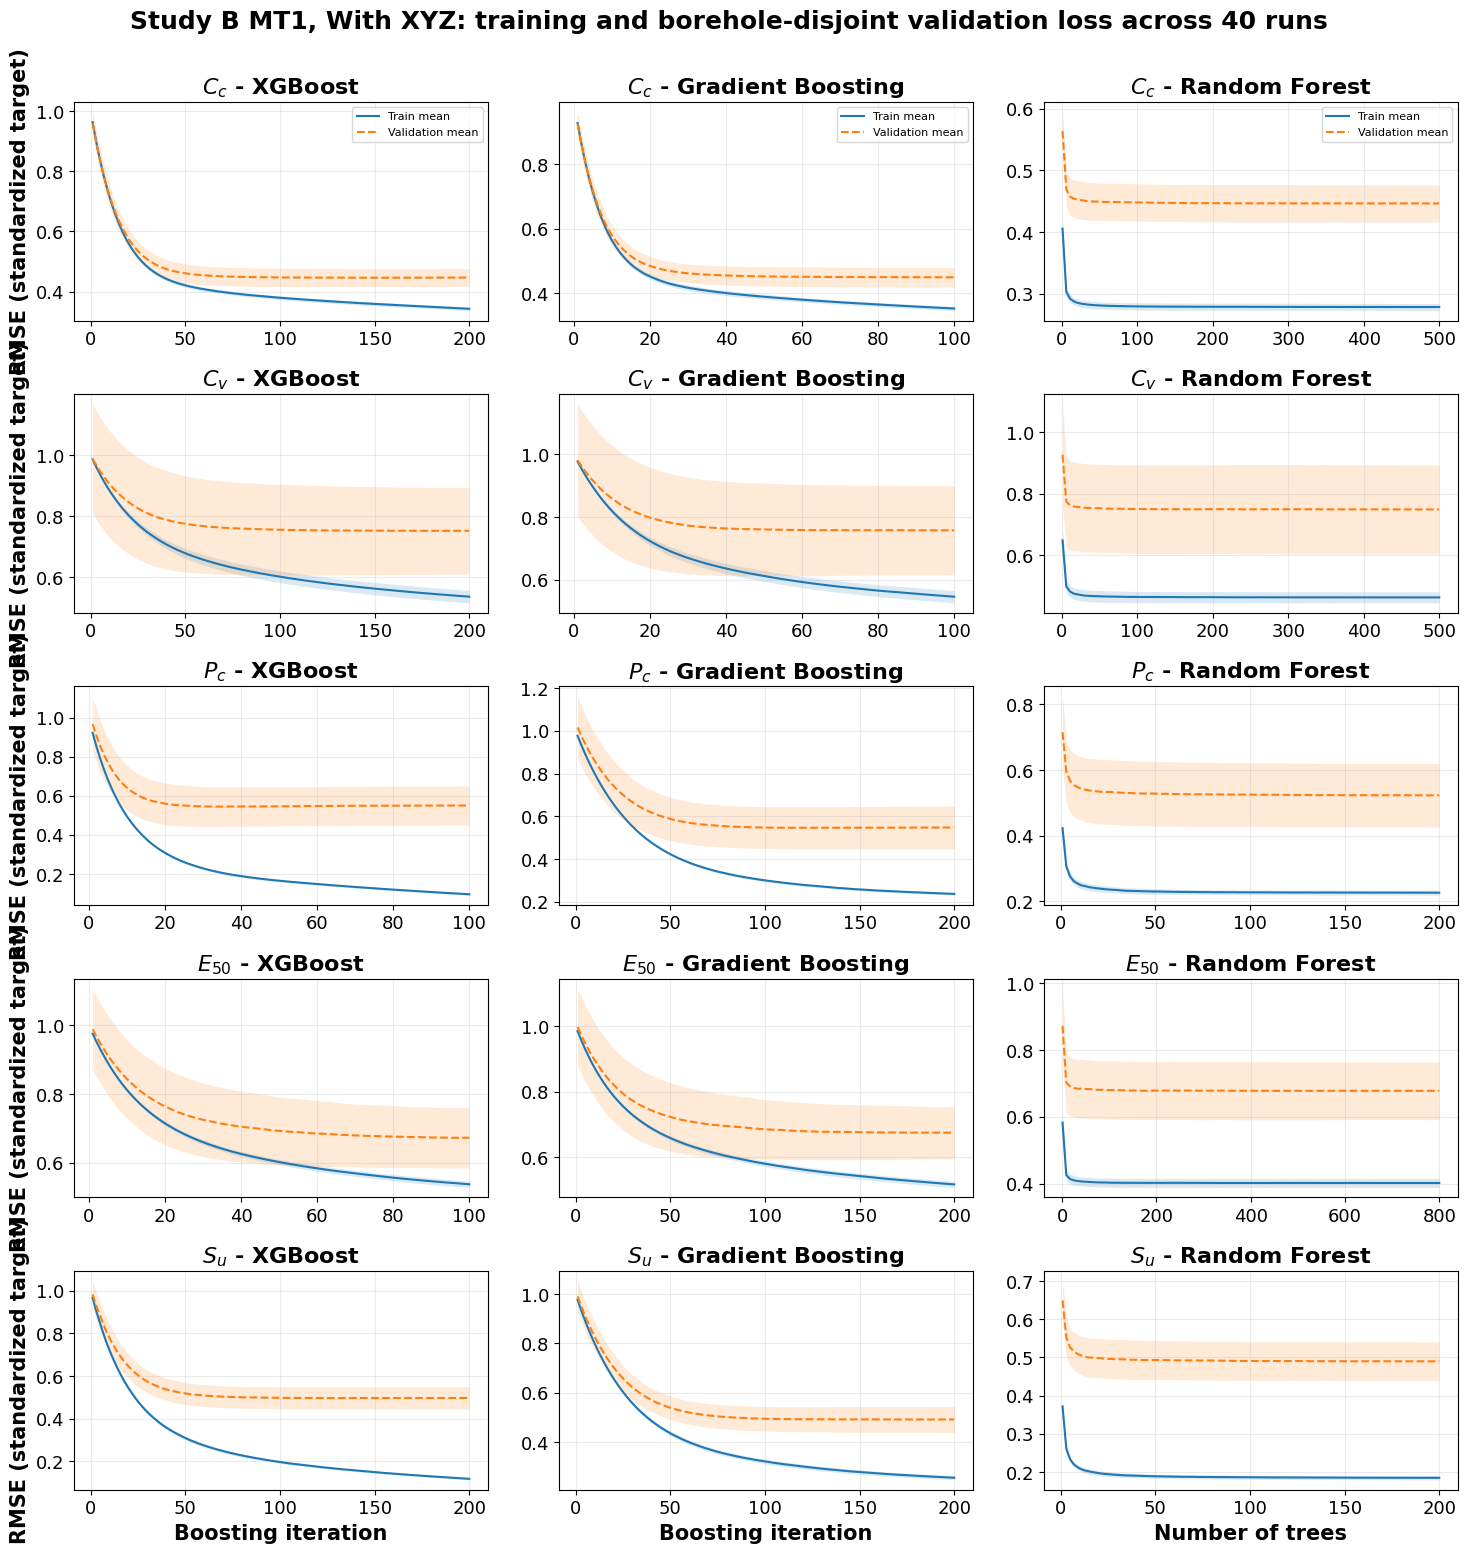

,Component,Configuration
0,Operating system,Linux-4.18.0-193.6.3.el8_2.x86_64-x86_64-with-...
1,Machine architecture,x86_64
2,CPU model,x86_64
3,Physical CPU cores,128
4,Logical CPU cores,128
5,System memory,503.10 GiB
6,"GPU name, memory, driver",not detected
7,Python implementation,CPython
8,Python version,3.12.0


,Library,Version
0,NumPy,2.2.6
1,pandas,2.3.3
2,SciPy,1.16.3
3,scikit-learn,1.6.1
4,joblib,1.5.2
5,XGBoost,3.1.1
6,Matplotlib,3.10.7
7,SHAP,0.50.0
8,psutil,7.1.0
9,Jupyter,not installed


,Stage,Model,Timed operations,Total seconds,Total minutes,Mean seconds,SD seconds,Minimum seconds,Maximum seconds,Notes
0,Hyperparameter optimization,RF,56,5633.722710,93.895378,100.602191,63.471686,16.858413,213.190239,"One timed search per target, missing type, and..."
1,Hyperparameter optimization,GBR,56,2851.158938,47.519316,50.913552,33.720002,7.529868,109.591223,"One timed search per target, missing type, and..."
2,Hyperparameter optimization,XGB,56,1376.808859,22.946814,24.585872,17.379428,2.448107,57.072044,"One timed search per target, missing type, and..."
3,Multi-run loss-curve diagnostics,XGB,200,111.111907,1.851865,0.555560,0.327450,0.204057,1.231762,Borehole-disjoint development/validation split...
4,Multi-run loss-curve diagnostics,GBR,200,432.943522,7.215725,2.164718,1.634190,0.330151,4.237935,Borehole-disjoint development/validation split...
5,Multi-run loss-curve diagnostics,RF,200,3156.965639,52.616094,15.784828,5.335254,9.502702,25.101959,Borehole-disjoint development/validation split...


Reproducibility outputs written to /scratch/pm4167/BM2/BM2_Revision_Sept/StudyB/StudyB_40run_results_Selected23Sept


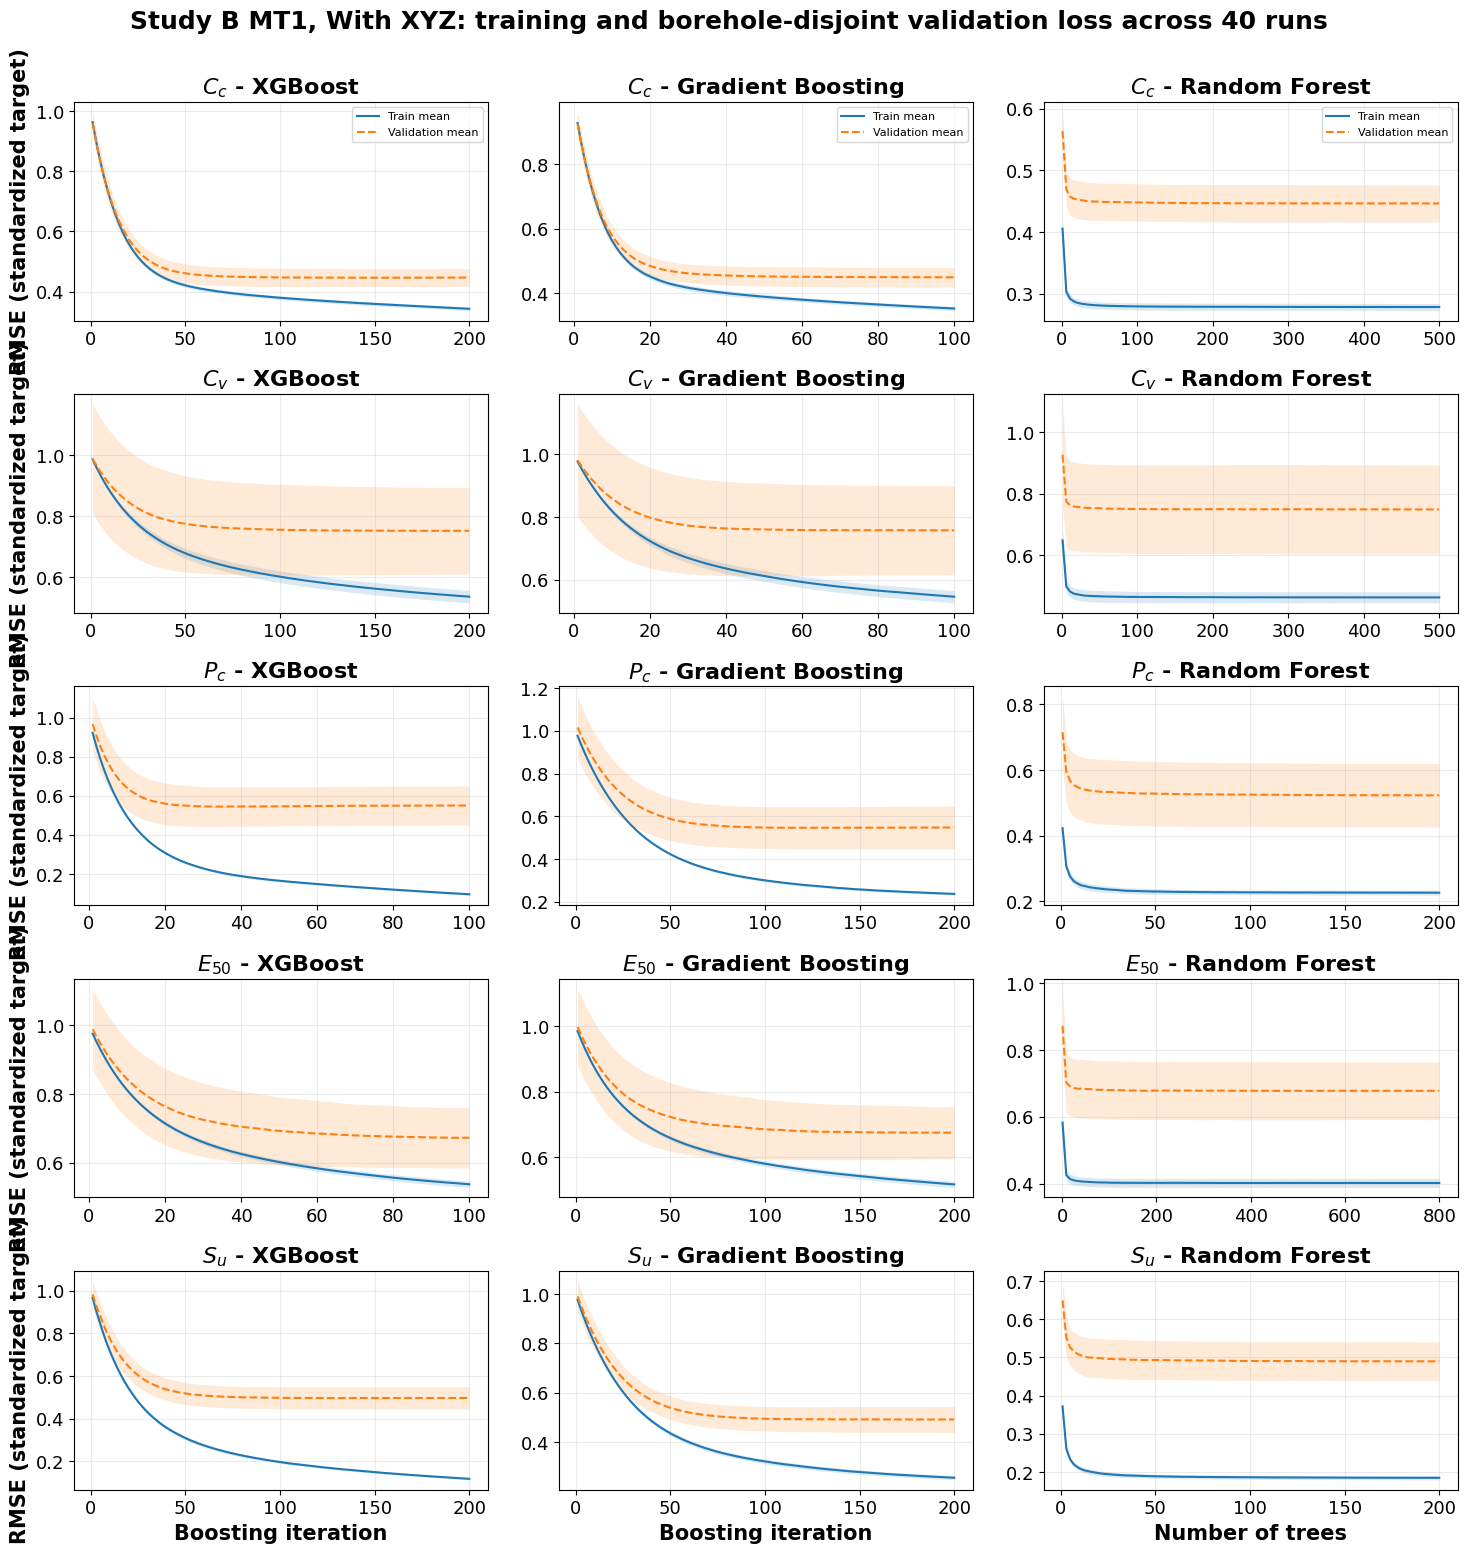

In [89]:
GENERATE_MULTIRUN_LOSS_CURVES = True
LOSS_CURVE_MISSING_TYPE = "MT1"
LOSS_CURVE_CONFIGURATION = "XYZ"
LOSS_CURVE_RUNS = 40
LOSS_CURVE_VALIDATION_FRACTION = 0.20
LOSS_CURVE_RF_MAX_POINTS = 100
LOSS_CURVE_SHOW_INDIVIDUAL_RUNS = False

diagnostic_args = notebook_args_namespace(NOTEBOOK_ARGS)
diagnostic_output_dir = Path(diagnostic_args.output_dir).expanduser().resolve()
selected_hyperparameters_path = diagnostic_output_dir / "selected_hyperparameters.csv"

loss_curve_values = pd.DataFrame()
loss_curve_timing = pd.DataFrame()
loss_curve_figure = None

if GENERATE_MULTIRUN_LOSS_CURVES:
    if not selected_hyperparameters_path.is_file():
        raise FileNotFoundError(
            f"{selected_hyperparameters_path} was not found. "
            "Run the complete experiment first so the diagnostic reuses locked "
            "hyperparameters without retuning."
        )
    diagnostic_development = load_development_pool(diagnostic_args)
    selected_hyperparameters = pd.read_csv(selected_hyperparameters_path)
    loss_curve_values, loss_curve_timing, loss_curve_figure = (
        generate_multirun_loss_curves(
            development=diagnostic_development,
            selected=selected_hyperparameters,
            output_dir=diagnostic_output_dir,
            missing_type=LOSS_CURVE_MISSING_TYPE,
            configuration=LOSS_CURVE_CONFIGURATION,
            runs=LOSS_CURVE_RUNS,
            base_seed=diagnostic_args.base_seed,
            validation_fraction=LOSS_CURVE_VALIDATION_FRACTION,
            rf_max_points=LOSS_CURVE_RF_MAX_POINTS,
            show_individual_runs=LOSS_CURVE_SHOW_INDIVIDUAL_RUNS,
        )
    )
    display(loss_curve_figure)

system_configuration, programming_libraries, computation_times = (
    write_reproducibility_report(
        diagnostic_output_dir,
        loss_curve_timing=loss_curve_timing,
    )
)
display(system_configuration)
display(programming_libraries)
display(computation_times)
print(f"Reproducibility outputs written to {diagnostic_output_dir}")


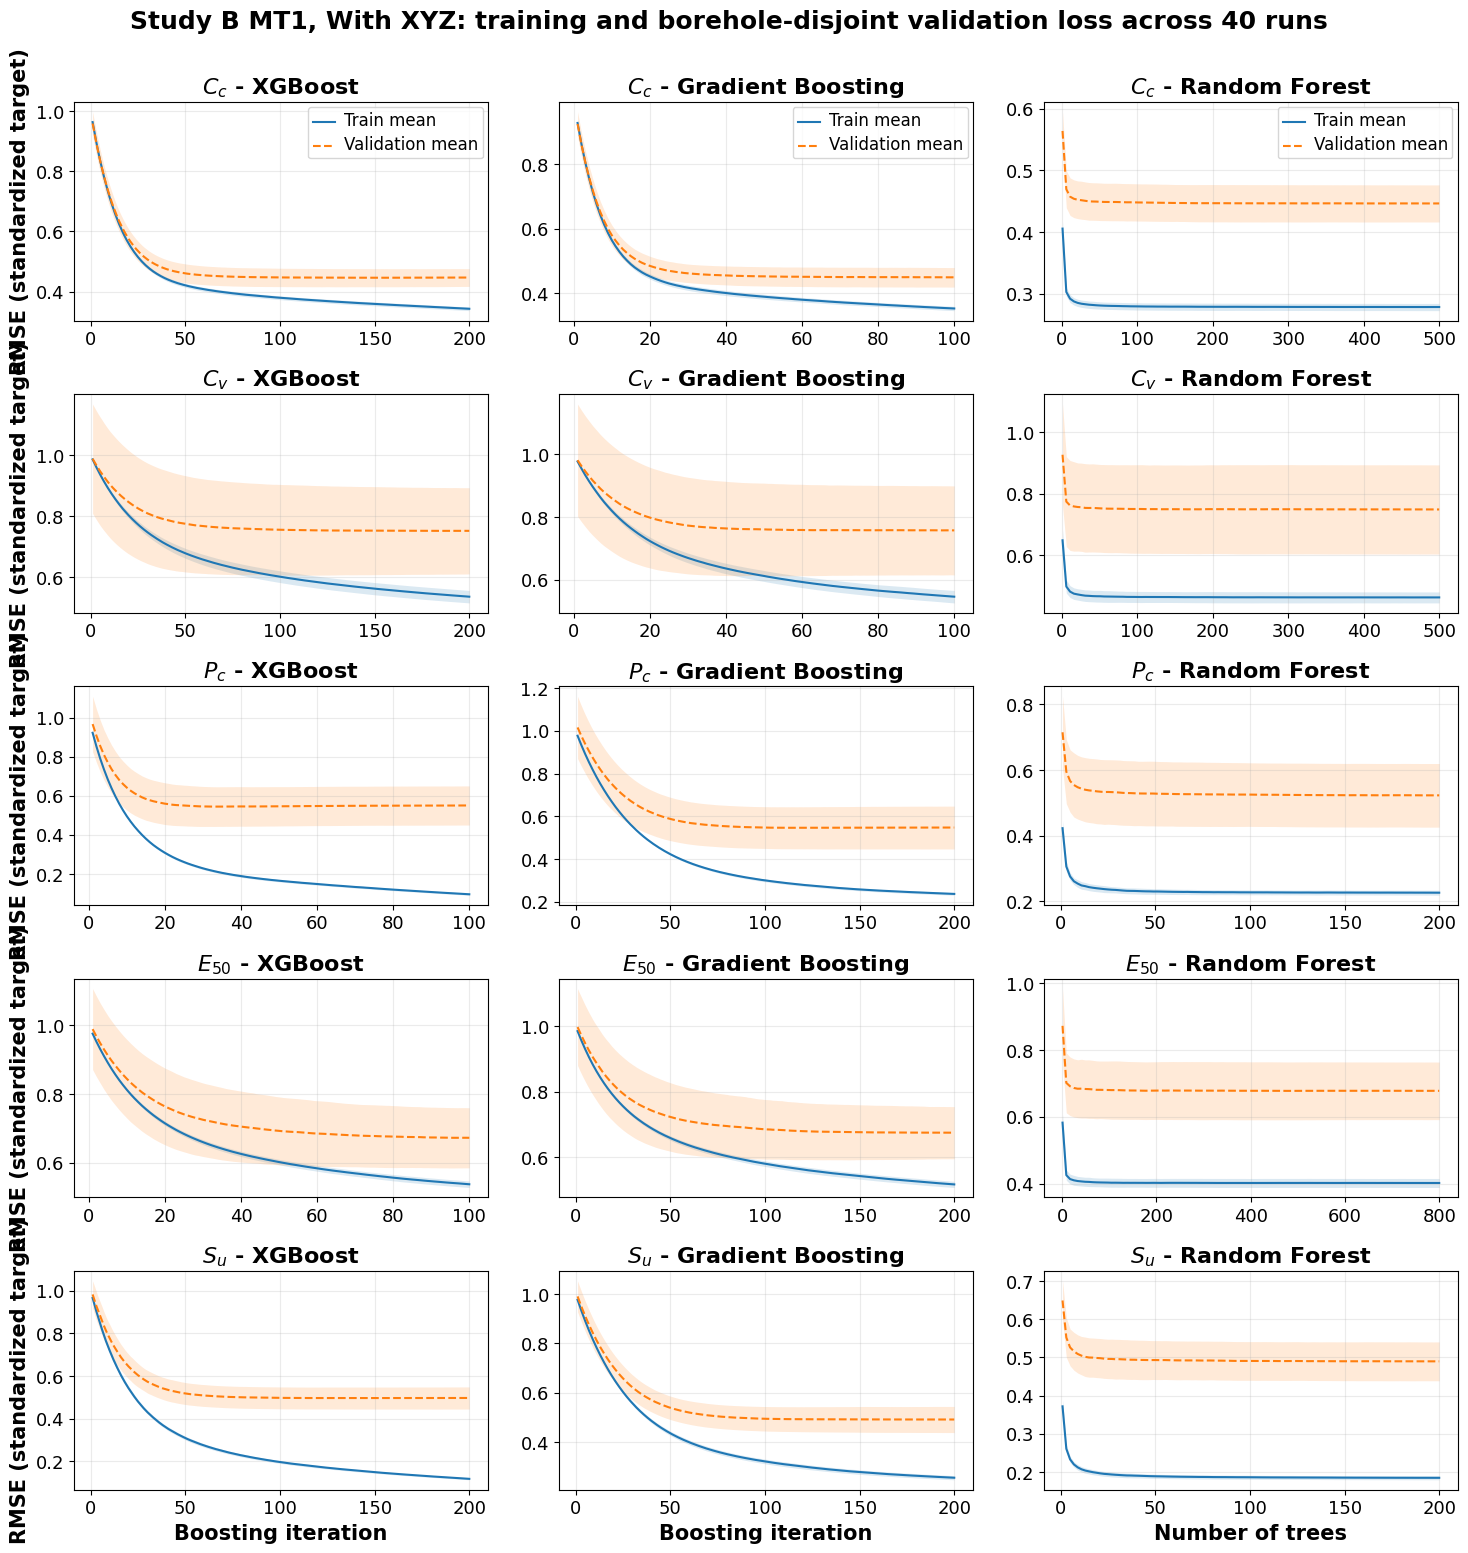

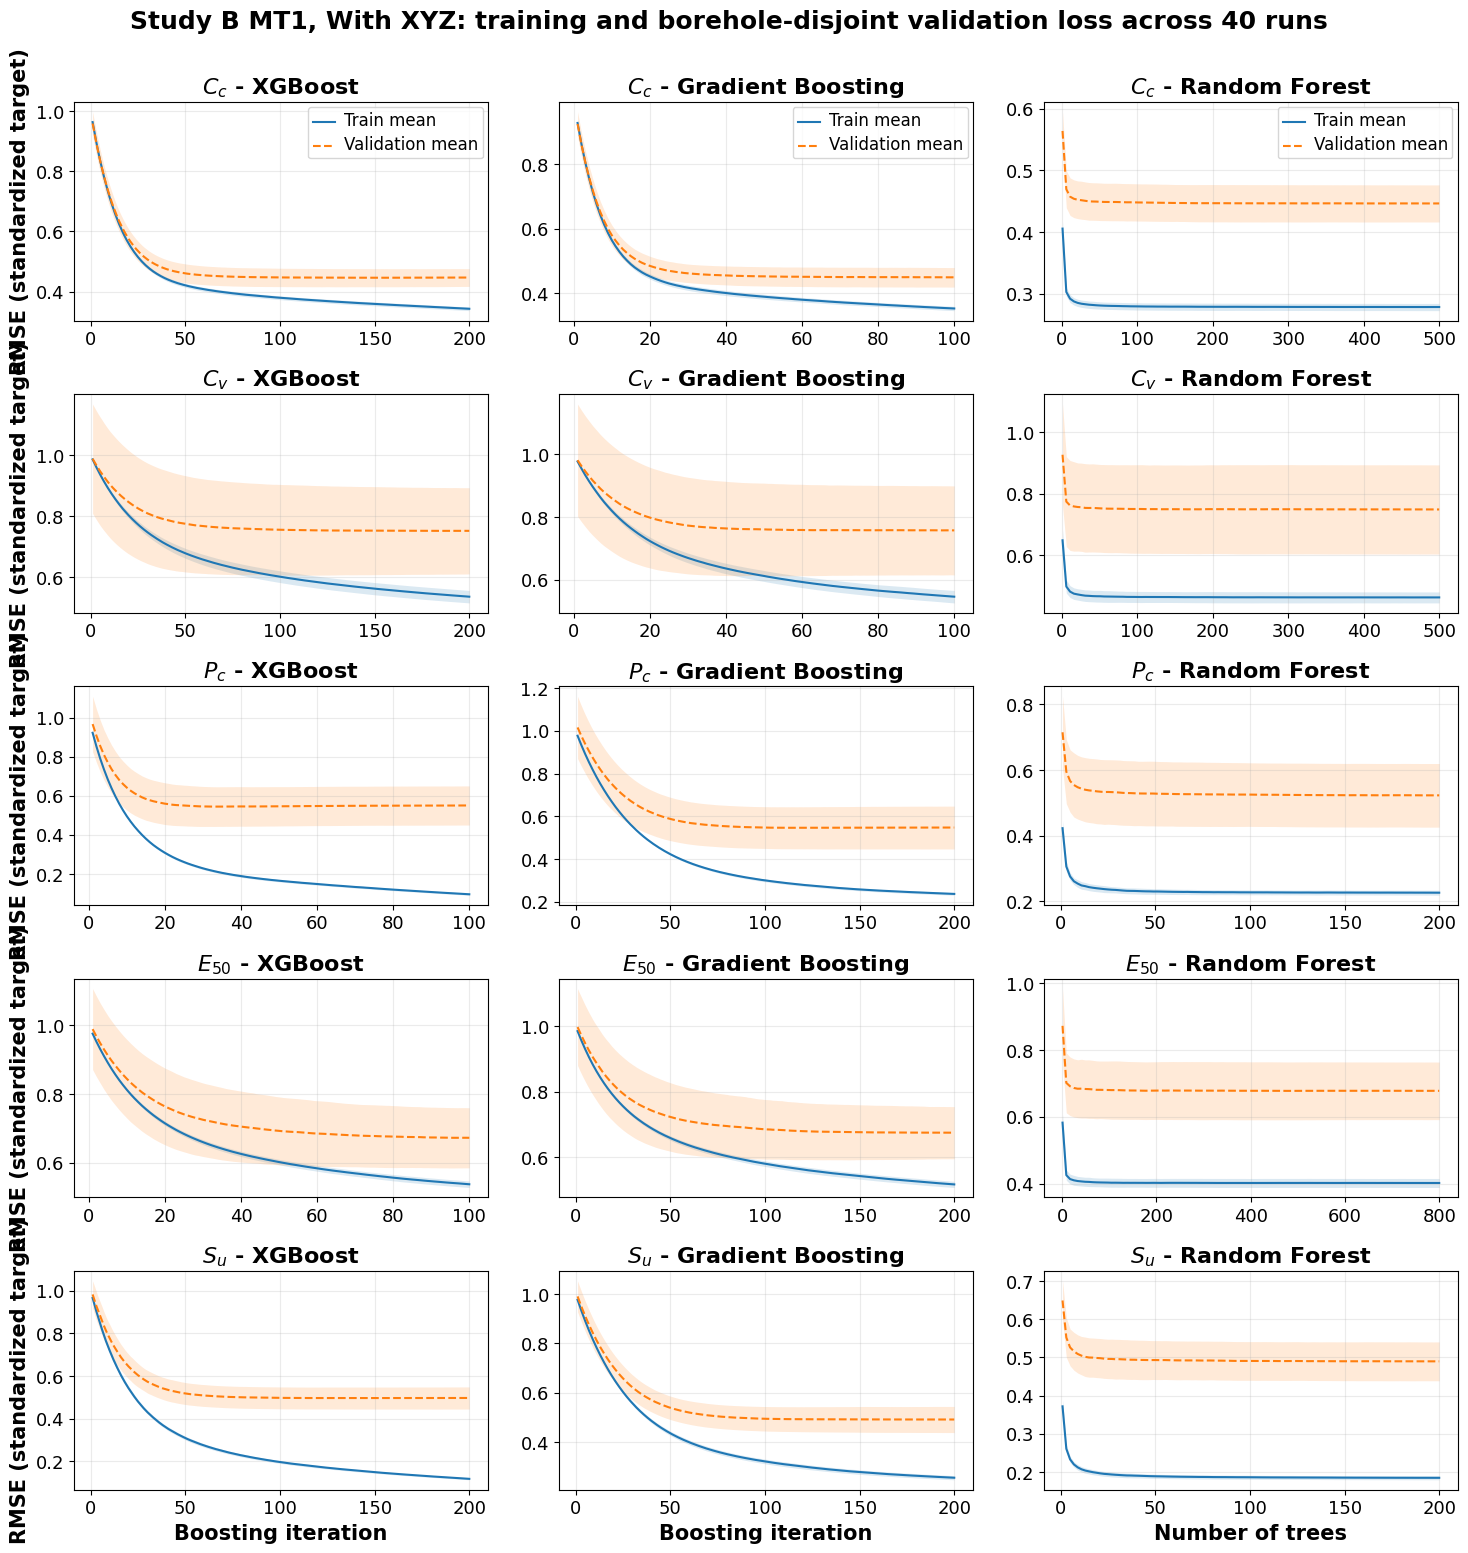

In [90]:
loss_curve_values, loss_curve_timing, loss_curve_figure = (
    generate_multirun_loss_curves(
        development=diagnostic_development,
        selected=selected_hyperparameters,
        output_dir=diagnostic_output_dir,
        missing_type=LOSS_CURVE_MISSING_TYPE,
        configuration=LOSS_CURVE_CONFIGURATION,
        runs=LOSS_CURVE_RUNS,
        base_seed=diagnostic_args.base_seed,
        validation_fraction=LOSS_CURVE_VALIDATION_FRACTION,
        rf_max_points=LOSS_CURVE_RF_MAX_POINTS,
        show_individual_runs=LOSS_CURVE_SHOW_INDIVIDUAL_RUNS,
    )
)

# ------------------------------------------------------------
# Enlarge all text in the returned figure
# ------------------------------------------------------------

if loss_curve_figure is not None:

    # Main figure heading
    if loss_curve_figure._suptitle is not None:
        loss_curve_figure._suptitle.set_fontsize(18)
        loss_curve_figure._suptitle.set_fontweight("bold")

    for ax in loss_curve_figure.get_axes():

        # Subplot heading
        ax.title.set_fontsize(16)
        ax.title.set_fontweight("bold")

        # X-axis and y-axis labels
        ax.xaxis.label.set_fontsize(15)
        ax.xaxis.label.set_fontweight("semibold")

        ax.yaxis.label.set_fontsize(15)
        ax.yaxis.label.set_fontweight("semibold")

        # X-axis and y-axis tick values
        ax.tick_params(
            axis="both",
            which="major",
            labelsize=13,
        )

        ax.tick_params(
            axis="both",
            which="minor",
            labelsize=11,
        )

        # Legend text
        legend = ax.get_legend()

        if legend is not None:
            for legend_text in legend.get_texts():
                legend_text.set_fontsize(12)

            legend_title = legend.get_title()
            if legend_title is not None:
                legend_title.set_fontsize(13)
                legend_title.set_fontweight("semibold")

    loss_curve_figure.canvas.draw_idle()

display(loss_curve_figure)

In [91]:
updated_png = (
    diagnostic_output_dir
    / (
        f"loss_curves_{LOSS_CURVE_MISSING_TYPE}_"
        f"{LOSS_CURVE_CONFIGURATION}_large_fonts.png"
    )
)

updated_pdf = updated_png.with_suffix(".pdf")

loss_curve_figure.savefig(
    updated_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

loss_curve_figure.savefig(
    updated_pdf,
    bbox_inches="tight",
    facecolor="white",
)

## Principal outputs

- `Table2_StudyA_MT1_mean_SD.csv`
- `Table3_StudyA_model_ablation_mean_SD.csv`
- `Table4_StudyA_train_test_improvements_mean_SD.csv`
- `StudyA_manuscript_tables_40_runs.xlsx`
- `summary_metrics_mean_sd_ci95.csv`
- `run_metrics_all_models.csv`
- `test_predictions_all_runs.csv`, containing only the five mapped test rows for each missing type
- `selected_hyperparameters.csv`
- `paired_wilcoxon_tests_test_RMSE.csv`
- `sample_count_and_overlap_audit.csv`, including the row mapping and selected record counts
- `feature_manifest.csv` and `experiment_manifest.json`
- `system_configuration.csv`, `programming_libraries.csv`, and `computation_times.csv`
- `reproducibility_tables.tex`
- `pipeline_wall_clock_time.csv`
- `StudyA_MT1_XYZ_multirun_loss_curves.png` and `.pdf`
- `StudyA_MT1_XYZ_multirun_loss_curve_values.csv` and `_timing.csv`
